# Exercise: Effect of rescaling on a k-neighbors models

In this exercise, we will use the **PRIMM** (Predict, Run, Investigate, Modify, Make) method to understand the importance of preprocessing numerical data—specifically, how feature scaling impacts distance-based algorithms like K-Nearest Neighbors (KNN).

## 1. Predict

Read the code in the “Run” section below, but **do not run it yet**.

We are using the `KNeighborsClassifier` on two features from the Breast Cancer dataset: `mean area` and `mean smoothness`.

- `mean area` has values that vary between approximately `143.5` and `2501.0`.
- `mean smoothness` has values that vary between approximately `0.05` and `0.16`.

We train a model on both the unscaled and scaled versions (using `StandardScaler`) of these two features.

**Predict:**

1. Will the decision boundaries for the model trained on unscaled data and scaled data be the same or different?
2. For the unscaled data, distances will be dominated by which feature? Why?

*Double click here to write your predictions:*

In [1]:
# Answer:
# 1. The decision boundaries will be different.
# 2. Distances will be dominated by "mean area" because it has much larger values.

## 2. Run

Run the following code block to visualize the decision boundary of the KNN classifier on the two versions of the data.

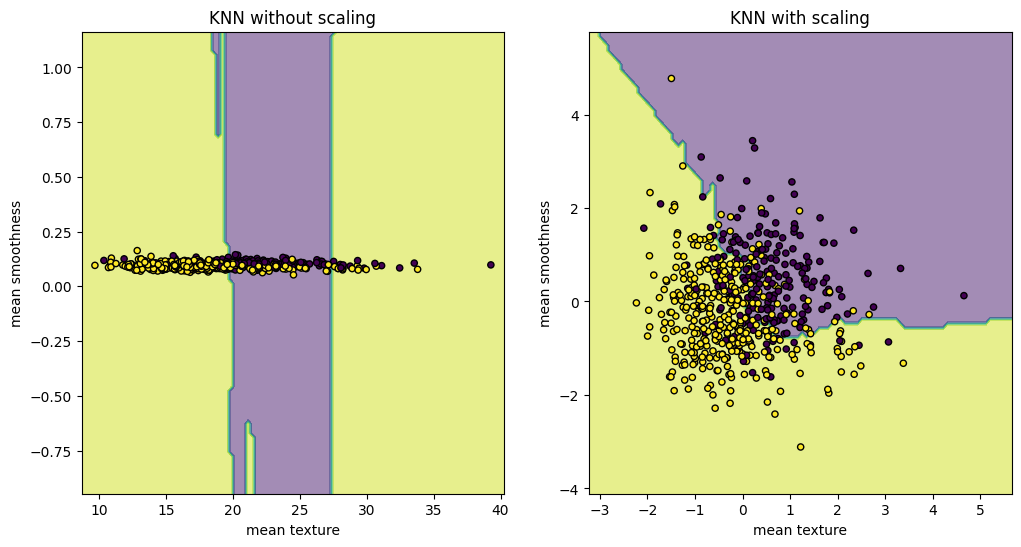

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier

cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target

features = ["mean texture", "mean smoothness"]
X_plot = X[features]

scaler = StandardScaler()
X_plot_scaled = pd.DataFrame(
    scaler.fit_transform(X_plot),
    columns=X_plot.columns
)

clf = KNeighborsClassifier(n_neighbors=20)

def fit_and_plot_model(X_data, y_data, clf, ax):
    clf.fit(X_data, y_data)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf, X_data, response_method="predict", alpha=0.5, ax=ax
    )
    disp.ax_.scatter(
        X_data[features[0]],
        X_data[features[1]],
        c=y_data,
        s=20,
        edgecolor="k"
    )
    return disp.ax_

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

fit_and_plot_model(X_plot, y, clf, ax1)
ax1.set_title("KNN without scaling")

fit_and_plot_model(X_plot_scaled, y, clf, ax2)
ax2.set_title("KNN with scaling")

plt.show()

## 3. Investigate

Review the output.

- Was your prediction correct?
- How did scaling affect the decision boundaries?
- Why does the left plot rely heavily on one feature?

*Double click here to write your investigation findings:*

In [3]:
# Answer:
# Yes, my prediction was correct.
# Scaling changed the decision boundary to be more balanced.
# Without scaling, the model depends heavily on one feature due to its large values.

## 4. Modify

1. Change `n_neighbors` (e.g., 1 or 50).
2. Replace `StandardScaler` with `MinMaxScaler`.

What changes do you observe?

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_plot_scaled = pd.DataFrame(
    scaler.fit_transform(X_plot),
    columns=X_plot.columns
)

clf = KNeighborsClassifier(n_neighbors=1)

In [5]:
# Answer:
# Changing neighbors changes the smoothness of the boundary.
# MinMaxScaler changes the scale but still improves model balance.

## 5. Make

Use two different features like `mean radius` and `mean texture`.

- Print min and max values
- Train KNN with and without scaling
- Plot decision boundaries
- Does scaling still matter?

*Write your own code below:*

In [6]:
X_new = cancer.data[['mean radius', 'mean texture']]

print(X_new.min())
print(X_new.max())

mean radius     6.981
mean texture    9.710
dtype: float64
mean radius     28.11
mean texture    39.28
dtype: float64


In [7]:
# Answer:
# Scaling still helps, but the impact may be smaller if features are closer in range.